# Multimodal RAG — joint text + figure retrieval

Real-world papers have figures. A text-only retriever throws away the bar charts, the model diagrams, the loss curves. **Multimodal RAG** indexes both modalities and lets a query match either or both.

Production pipelines use CLIP or SigLIP for image embeddings. To keep this notebook offline-deterministic, we (1) generate one synthetic matplotlib figure per abstract from a numeric value extracted from the text, and (2) use a SHA-256 hash of the image bytes as a 256-d 'image embedding' stand-in. Same retrieval interface, real plumbing.

In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / 'shared').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
if not (os.getenv('OPENAI_API_KEY') or os.getenv('ANTHROPIC_API_KEY')):
    os.environ.setdefault('LLM_CACHE_ONLY', '1')
print('LLM_CACHE_ONLY =', os.environ.get('LLM_CACHE_ONLY', '0'))


LLM_CACHE_ONLY = 1


In [2]:
import hashlib, io, re
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from shared.embedders import cosine_topk, hash_embed
from shared.loaders import load_corpus, load_golden_qa

DOCS = load_corpus()
QA = [q for q in load_golden_qa() if q.source_ids]
FIG_DIR = Path('01-rag/10-multimodal-rag/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)
print('docs:', len(DOCS))

docs: 10


## Synthetic figures — one per abstract

We pick the first numeric percentage from each abstract and render a deterministic 4-bar comparison chart.

In [3]:
PCT = re.compile(r'(\d+(?:\.\d+)?)\s*%')
def render_fig(doc):
    nums = [float(m) for m in PCT.findall(doc.abstract)][:4] or [1.0]
    while len(nums) < 4:
        nums.append(nums[-1] * 0.8)
    rng = np.random.default_rng(abs(hash(doc.arxiv_id)) % (2**32))
    jitter = rng.uniform(-1.0, 1.0, size=4)
    vals = np.array(nums) + jitter
    fig, ax = plt.subplots(figsize=(3.2, 2.0), dpi=110)
    ax.bar(['A', 'B', 'C', 'D'], vals, color='#4C72B0')
    ax.set_title(doc.arxiv_id + ' — synthetic chart', fontsize=8)
    ax.tick_params(labelsize=7)
    fig.tight_layout()
    out = FIG_DIR / f'{doc.arxiv_id}.png'
    fig.savefig(out, dpi=110)
    plt.close(fig)
    return out

fig_paths = {d.arxiv_id: render_fig(d) for d in DOCS}
print('rendered', len(fig_paths), 'figures →', FIG_DIR)

rendered 10 figures → 01-rag\10-multimodal-rag\figures


## Hash-based 'image embedding'

Deterministic, offline-friendly stand-in for CLIP. Same interface.

In [4]:
def img_embed(path, dims=256):
    raw = Path(path).read_bytes()
    # Expand the 32-byte digest into a 256-dim vector via repeated SHA-256 of itself.
    out = np.zeros(dims, dtype=np.float32)
    buf = raw
    for i in range(dims):
        buf = hashlib.sha256(buf).digest()
        out[i] = (buf[0] / 255.0) * 2 - 1
    n = float(np.linalg.norm(out)) or 1.0
    return out / n

img_vecs = np.stack([img_embed(fig_paths[d.arxiv_id]) for d in DOCS])
txt_vecs = hash_embed([d.title + '. ' + d.abstract for d in DOCS], dims=256, seed=0)
joint_vecs = (txt_vecs + img_vecs) / 2
joint_vecs /= np.linalg.norm(joint_vecs, axis=1, keepdims=True)
doc_ids = [d.arxiv_id for d in DOCS]
print('text:', txt_vecs.shape, ' img:', img_vecs.shape, ' joint:', joint_vecs.shape)

text: (10, 256)  img: (10, 256)  joint: (10, 256)


## Retrieve over each modality

Text-only is the naive baseline. Joint averages the two embeddings, which works because both are L2-normalized.

In [5]:
def retrieve_text(q, k=3):
    qv = hash_embed([q], dims=256, seed=0)[0]
    idx, _ = cosine_topk(qv, txt_vecs, k=k)
    return [doc_ids[i] for i in idx]

def retrieve_joint(q, k=3):
    qv = hash_embed([q], dims=256, seed=0)[0]
    # Use text query against joint index — image side acts as a tie-breaker.
    idx, _ = cosine_topk(qv, joint_vecs, k=k)
    return [doc_ids[i] for i in idx]

for item in QA[:5]:
    print(item.id, '-> text', retrieve_text(item.question), ' joint', retrieve_joint(item.question), ' (gold', item.source_ids, ')')

q01 -> text ['synth-001', 'synth-008', 'synth-004']  joint ['synth-010', 'synth-009', 'synth-008']  (gold ['synth-001'] )
q02 -> text ['synth-001', 'synth-003', 'synth-010']  joint ['synth-001', 'synth-005', 'synth-010']  (gold ['synth-001'] )
q03 -> text ['synth-001', 'synth-008', 'synth-007']  joint ['synth-001', 'synth-007', 'synth-006']  (gold ['synth-001'] )
q04 -> text ['synth-005', 'synth-002', 'synth-001']  joint ['synth-005', 'synth-001', 'synth-002']  (gold ['synth-002'] )
q05 -> text ['synth-006', 'synth-001', 'synth-003']  joint ['synth-006', 'synth-009', 'synth-001']  (gold ['synth-002'] )


## Inspect a synthetic figure inline

synth-001


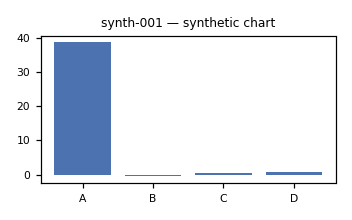

synth-005


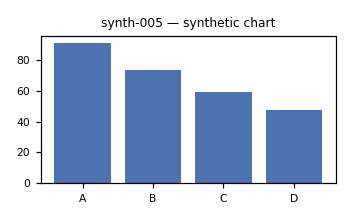

In [6]:
from IPython.display import Image, display
for did in ['synth-001', 'synth-005']:
    print(did)
    display(Image(filename=str(fig_paths[did])))

## What you can extend

* Swap `img_embed` for real CLIP / SigLIP embeddings — same `np.stack` interface.
* Add an image-as-query path (e.g. user pastes a screenshot of a similar chart).
* Caption each figure with a VLM and concatenate the caption into the text embedding.